In [133]:
import os
import tarfile 
import urllib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from zlib import crc32
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import joblib
from sklearn.model_selection import GridSearchCV
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [3]:
# 1. Read Csv
housing = pd.read_csv("housing.csv")

In [4]:
# 2. Check The Data Structure
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# 3. Check The Info
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
# 4. Value Counts
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:

# 5. Describe
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


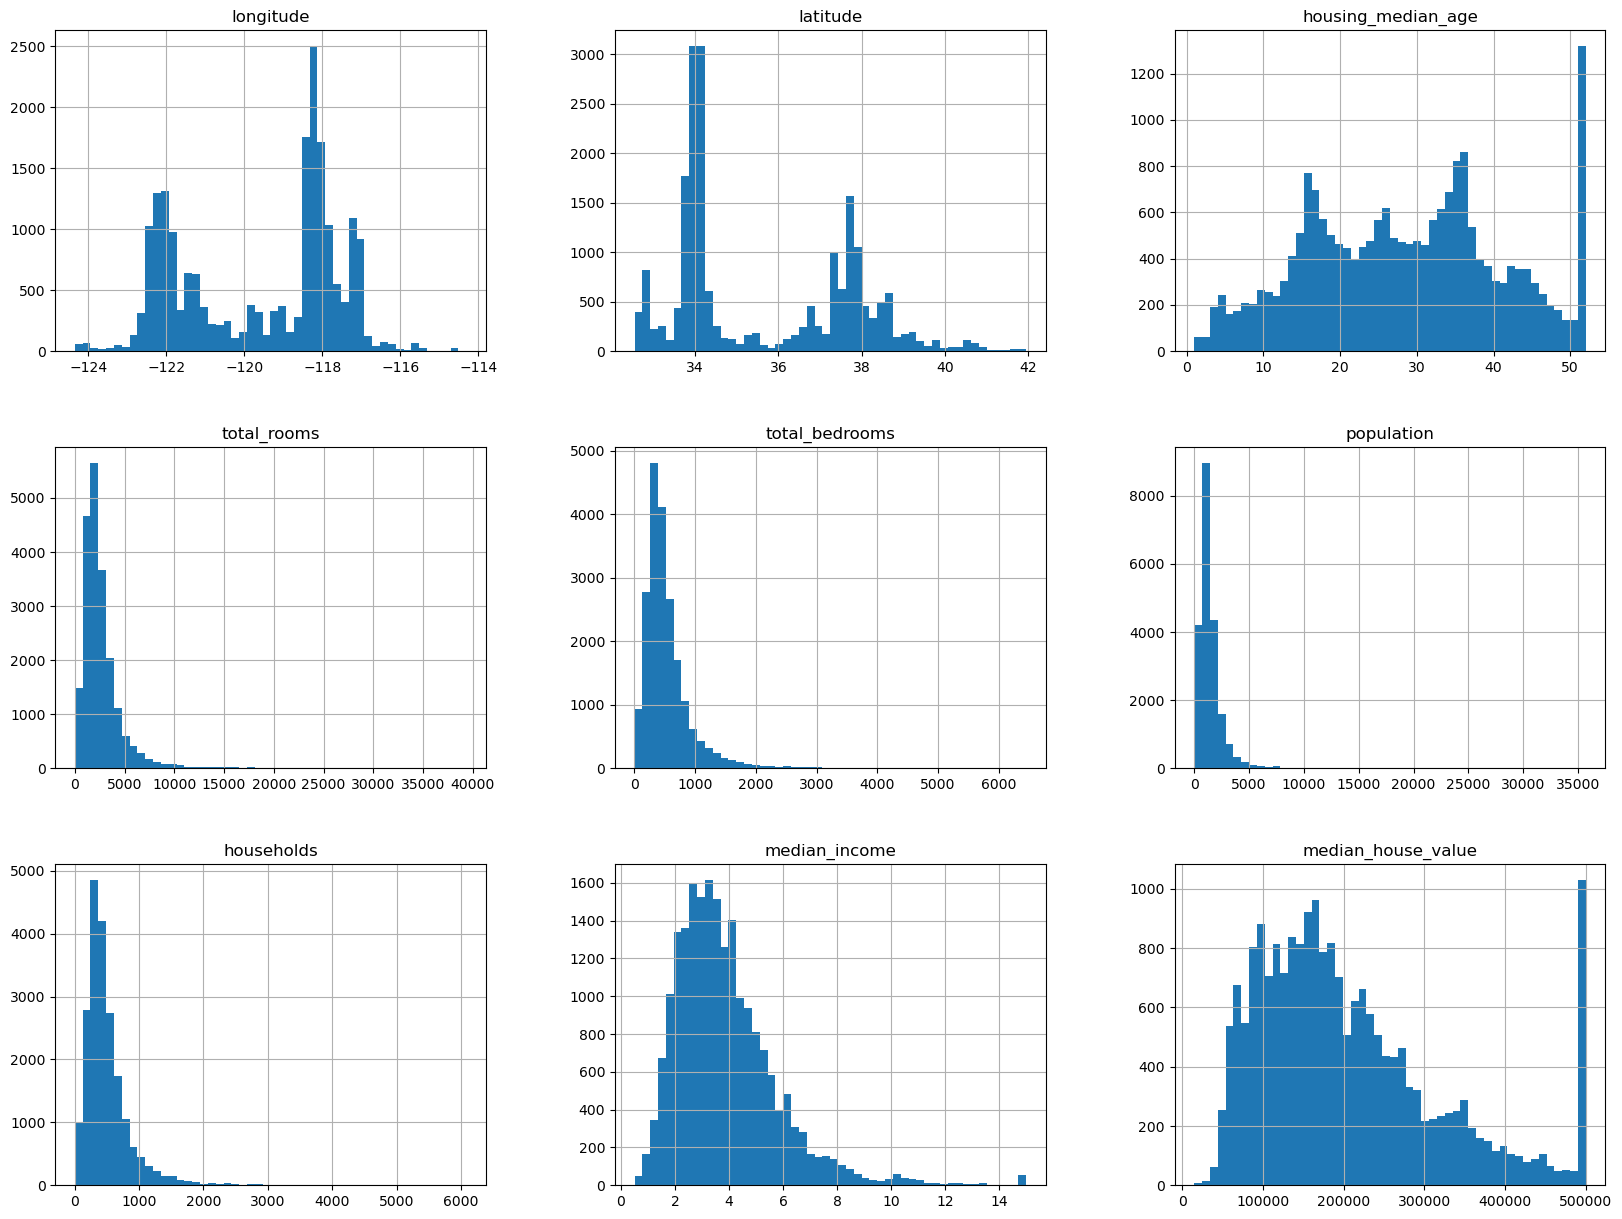

In [8]:
# 6. Histograms
%matplotlib inline
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [9]:
# 7. Split Train Test
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]
    


In [10]:
# 8. Use Function
train_set, test_set = split_train_test(housing, 0.2)


In [11]:
# 9. Checking Train And Test Set
len(train_set)

16512

In [12]:
len(test_set)

4128

In [13]:
# .10 Possible Solution Of The Code .7
def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32


In [14]:
# 11. Split Train Test By Id
def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[-in_test_set], data.loc[in_test_set]

In [15]:
# 12. Use Row Index As Id
housing_with_id = housing.reset_index() #adds on "index" column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [16]:
# 13. Combine Them Into An ID
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [17]:
# 14. Another Way Of Splitting
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)


In [18]:
# 15. Create An Income Category Attribute With Five Categories
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins =[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

<Axes: >

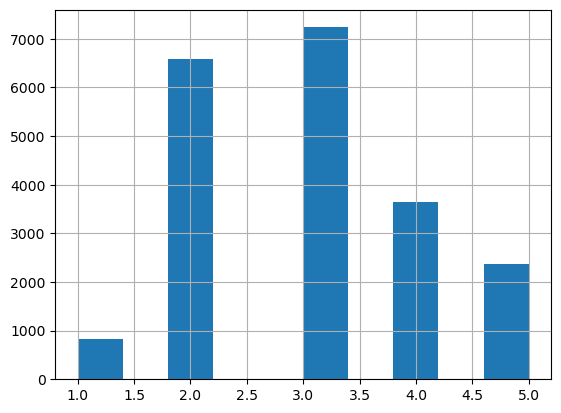

In [19]:
# 16. Histogram Of The Categories 
housing["income_cat"].hist()

In [20]:
# 17. Stratified Sampling Based On The Income Category
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]
    

In [21]:
# 18. Looking In The Income Categories Proportions In The test Set
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [22]:
# 19. Remove income_cat Attribute So The Data Is Back To Its Original State
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [23]:
# 20. Copy Of The Training Set
housing = strat_train_set.copy()


<Axes: xlabel='longitude', ylabel='latitude'>

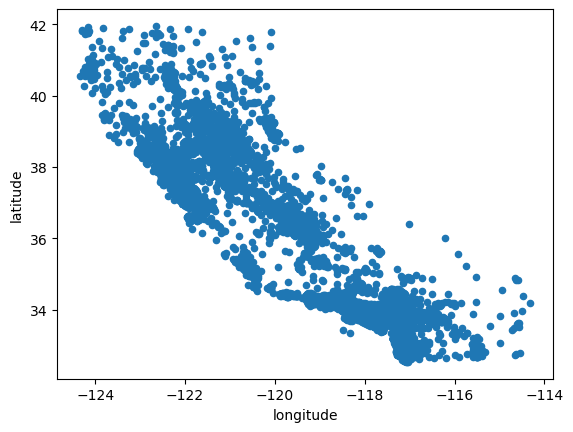

In [24]:
# 21. Scatter Plot Of All Districts
housing.plot(kind="scatter", x="longitude", y="latitude",)

<Axes: xlabel='longitude', ylabel='latitude'>

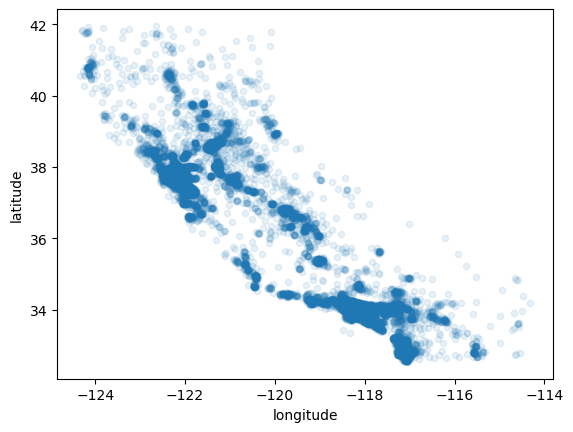

In [25]:
# 22. Visualize The Places Where There Is a high Density Of Data Points
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

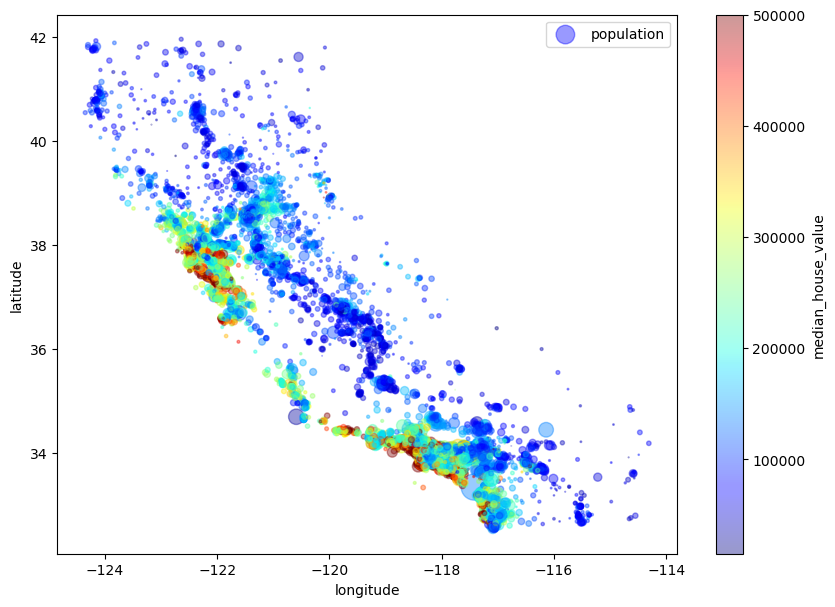

In [26]:
# 23. Housing Prices Plot
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
            )

plt.legend()
             
             

In [27]:
# 24. Compute The Standart Correlation Coefficient
corr_matrix = housing.corr(numeric_only=True)

In [28]:
# 25. How Each Attribute Correlates With The Median House Value
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

C:\Users\spiro\AppData\Local\Temp\ipykernel_41344\3131088478.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


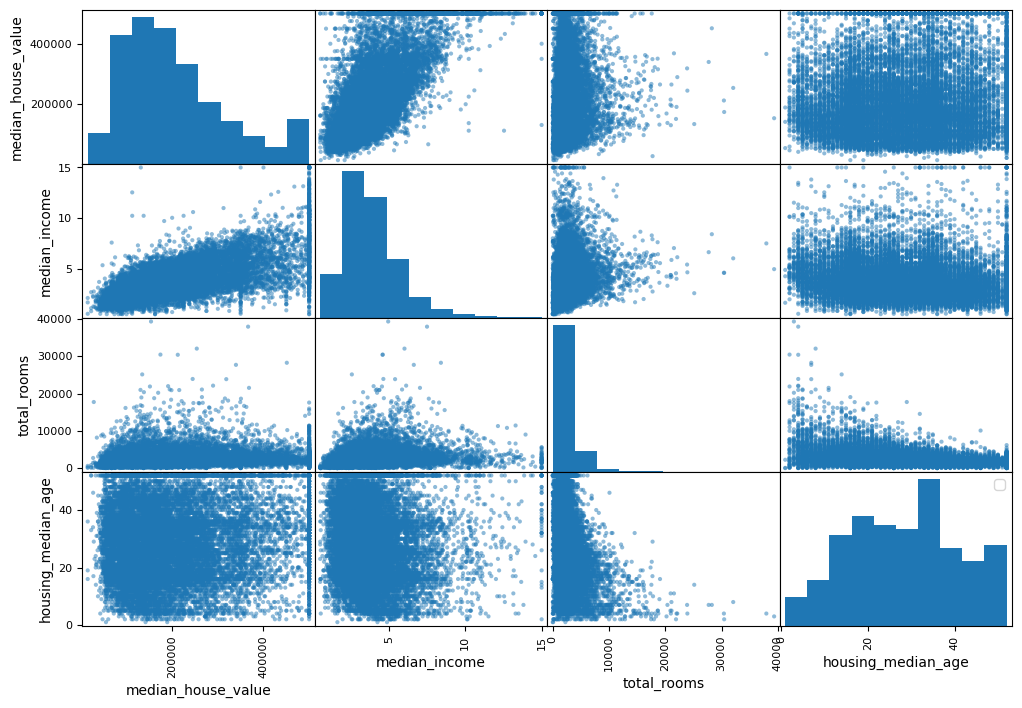

In [29]:
# 26. Another Way To CHeck For Correlation Between Attributes With Plots
# This Scatter Matrix Plots Every Numerical Attribute Vs Every Other Numerical Attribute
attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))
plt.legend()

C:\Users\spiro\AppData\Local\Temp\ipykernel_41344\579779232.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


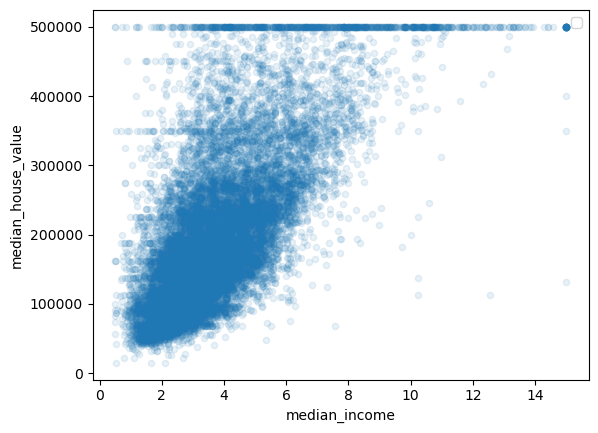

In [30]:
# 27. Plot The Most Promising Attribute
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)

plt.legend()

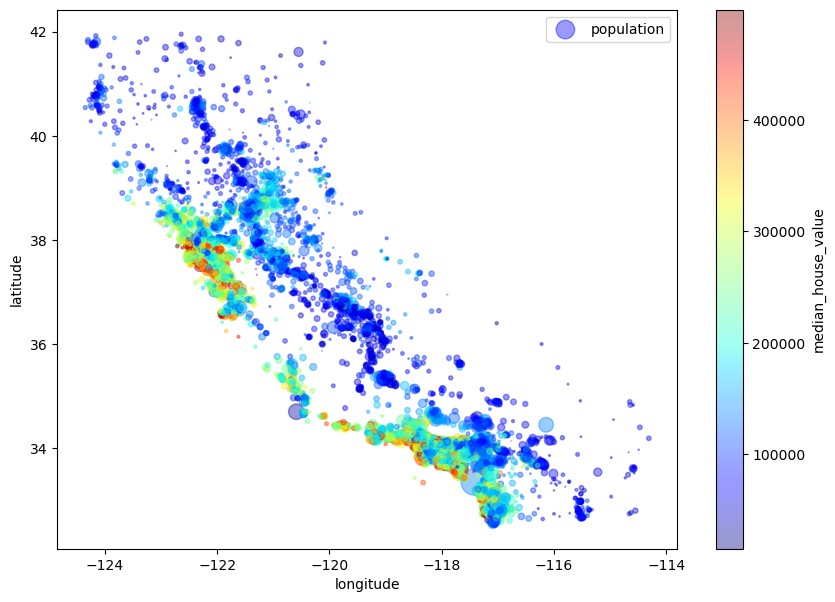

In [31]:
# 28. Remove The Data Quirks

housing = housing[housing["median_house_value"] < 500000]


housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
                     s=housing["population"]/100, label="population", figsize=(10,7),
                     c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()
plt.show()


In [32]:
# 29. Remove Data Quirks No 2
housing_cleaned = housing[
    (housing["median_house_value"] < 500000) & 
    (housing["median_house_value"] != 450000) & 
    (housing["median_house_value"] != 350000) & 
    (housing["median_house_value"] != 250000)
]


C:\Users\spiro\AppData\Local\Temp\ipykernel_41344\235311995.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


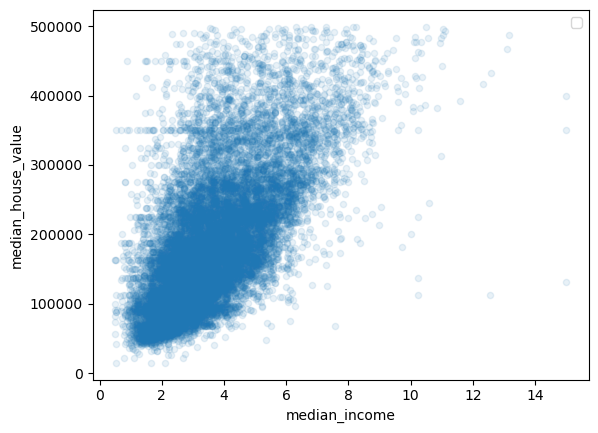

In [33]:
# 30. See The Results
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)

plt.legend()

In [34]:
# 31. Create New Attributes
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"] = housing["population"]/housing["households"]

In [35]:
# 32. Check The Correlation Matrix Again
corr_matrix = housing.corr(numeric_only=True)


In [36]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.644897
total_rooms                 0.145167
rooms_per_household         0.107339
households                  0.095630
total_bedrooms              0.074371
housing_median_age          0.071053
population                  0.012130
population_per_household   -0.019408
longitude                  -0.042272
latitude                   -0.151721
bedrooms_per_room          -0.225087
Name: median_house_value, dtype: float64

In [37]:
# 33. Processing - Seperate Predictors Labels And Revert To A Clean Training Set
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()


In [38]:
# 34. Options For Fixing Missing Values
#housing.dropna(subset=["total_bedrooms"]) # option 1
#housing.drop("total_bedrooms", axis=1) # option 2
#housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median) # option 3


In [39]:
# 35. We Save The Median Only In training Set
median = housing["total_bedrooms"].median()

In [40]:
# 36. Option three
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)

In [41]:
# 37. Using Simple Imputer, specifying that you want to replace each attribute’s missing values with the median of that
#attribute
imputer = SimpleImputer(strategy="median")

In [42]:
# 38. To calculate The Median We Need Only Numerical Attributes
housing_num = housing.drop("ocean_proximity", axis=1)

In [43]:
# 39. Fit The Imputer To The Training Data
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [44]:
# 40. Check The Imputer Statistics
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [45]:
# 41. Checking The Housing Num Median Values
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [46]:
# 42. Transform Training Set By Replacing Missing Values With The Learned Medians
X = imputer.transform(housing_num)

In [47]:
# 43. We Convert A Plain Numpy Array Into A Pandas Dataframe
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                         index=housing_num.index)

In [48]:
# 44. Ocean_Proximity Its Value For The 10 Instances
housing_cat = housing[["ocean_proximity"]]

In [49]:
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [50]:
# 45. Convert Categories From Text To Numbers
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [51]:
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [52]:
# 46. Get The List Of Categories
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [53]:
# 47. Convert Categorical Values Into One-Hot-Vectors
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [54]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [55]:
# 48. Convert To A Dense Numpy Array
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [56]:
# 49. Get The List Of Categories
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [57]:
# 50. Transformer Class That Adds The Combined Attributes
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6



In [58]:
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
        
   
    def fit(self, X, y=None):
        return self # nothing else to do
        
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix] 
        
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
           
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
           
            return np.c_[X, rooms_per_household, population_per_household]
    

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

In [59]:
# 51. Small Pipeline For The Numerical Attributes
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler()),
])

In [60]:
# 52. Execution Of All The Pipeline In Numerical Attributes
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [61]:
# 53 Apply All The Transformations To The Housing Data To Handle All Columns
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

In [62]:
# 54. Execution Of The Full Pipeline
housing_prepared = full_pipeline.fit_transform(housing)

In [63]:
# 55. Train A LinearRegression Model
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
# 56. Try Out On A Few Instances From The Training Set
some_data = housing.iloc[:5]

In [65]:
some_labels = housing_labels.iloc[:5]

In [66]:
some_data_prepared = full_pipeline.transform(some_data)

In [67]:
print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


In [68]:
print("Labels:", list(some_labels))

Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [69]:
# 57. Measure The Regression Models RMSE On The Whole Trainig Set 
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)


In [70]:
lin_rmse

np.float64(68627.87390018745)

In [71]:
# 58. Train A DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [72]:
# 59. Predict & Evaluate it On The Training Set
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)

In [73]:
tree_rmse

np.float64(0.0)

In [74]:
# 60. Use Kfold Cross Validation 
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [75]:
# 61. Look At The Results
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("standard deviation:", scores.std())

In [76]:
display_scores(tree_rmse_scores)

Scores: [70897.92496744 70786.59352192 67994.12151557 72508.09557456
 70936.62454982 77286.7488393  69912.09865613 73256.70432009
 68450.43056383 72381.24725958]
Mean: 71441.05897682518
standard deviation: 2522.5365922493806


In [77]:
# 62. Compute The Same Scores For LinearRegression Model
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

In [78]:
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
standard deviation: 2880.328209818069


In [79]:
# 63. Train A Random Forest Model
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
# 64. Predict & Evaluate it On The Training Set
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)

In [81]:
forest_rmse

np.float64(18868.4587791463)

In [82]:
# 65. Compute The Same Scores For RandomForestRegressor Model
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)

In [83]:
display_scores(forest_rmse_scores)

Scores: [51792.23230984 49009.36584758 46771.51763499 51890.62473642
 47598.77125514 52264.49615115 52356.90761122 49633.93668864
 48791.13989219 53623.95250455]
Mean: 50373.29446317193
standard deviation: 2190.3140880734195


In [84]:
# 66. Train SVR Model With Linear Kernel
svm_linear_reg = SVR(kernel="linear")
svm_linear_reg.fit(housing_prepared, housing_labels)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [85]:
# 67. Preidct & Evaluate it On The Training Set
svm_linear_predictions = svm_linear_reg.predict(housing_prepared)
svm_linear_mse = mean_squared_error(housing_labels, svm_linear_predictions)
svm_linear_rmse = np.sqrt(svm_linear_mse)

In [86]:
svm_linear_mse

12342113767.959623

In [87]:
# 68. Compute The Same Scores For SVR Model With Linear Kernel
svm_linear_scores = cross_val_score(svm_linear_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
svm_linear_rmse_scores = np.sqrt(-svm_linear_scores)

In [88]:
display_scores(svm_linear_rmse_scores)

Scores: [110518.40356474 112956.5486846  106998.56227015 113590.97575445
 107782.52294955 116063.7781669  113279.08892636 111836.81295967
 113168.96643781 111945.40954593]
Mean: 111814.1069260169
standard deviation: 2600.840269089257


In [89]:
# 68. Train SVR Model With None Linear Kernel (RBF)
svm_rbf_reg = SVR(kernel="rbf")
svm_rbf_reg.fit(housing_prepared, housing_labels)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [90]:
# 69. Preidct & Evaluate it On The Training Set
svm_rbf_predictions = svm_rbf_reg.predict(housing_prepared)
svm_rbf_mse = mean_squared_error(housing_labels, svm_rbf_predictions)
svm_rbf_rmse = np.sqrt(svm_rbf_mse)

In [91]:
svm_rbf_mse

14060906279.259628

In [92]:
# 70. Compute The Same Scores For SVR Model With Linear Kernel
svm_rbf_scores = cross_val_score(svm_rbf_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
svm_rbf_rmse_scores = np.sqrt(-svm_rbf_scores)

In [93]:
display_scores(svm_rbf_rmse_scores)

Scores: [116729.13778306 120113.99351281 113925.04340616 120399.11878641
 114687.49942071 122785.64737282 119853.79338279 118280.31108193
 120230.82615529 118840.1885232 ]
Mean: 118584.55594251942
standard deviation: 2609.6120823493407


In [94]:
# 71. Ceate A Save File
os.makedirs("my_models", exist_ok=True)


In [95]:
# 72. Save All The Models
joblib.dump(lin_reg, "my_models/01_linear_regression.pkl")
joblib.dump(tree_reg, "my_models/02_decision_tree.pkl")
joblib.dump(forest_reg, "my_models/03_random_forest.pkl")
joblib.dump(svm_linear_reg, "my_models/04_svm_linear.pkl")
joblib.dump(svm_rbf_reg, "my_models/05_svm_rbf.pkl")




['my_models/05_svm_rbf.pkl']

In [96]:
# 73. GridSearchCV For Random Forest Regressor
param_grid = [
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]},
    {"bootstrap":[False], "n_estimators": [3, 10], "max_features": [2, 3, 4]}
]

forest_reg = RandomForestRegressor()

grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True, n_jobs=-1)


In [97]:
grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [98]:
# 74. Best Combination Of Parameters
grid_search.best_params_


{'max_features': 6, 'n_estimators': 30}

In [99]:
# 75. New Best Estimator Directly
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
# 76. Try Grid Seach Again With Different Parameters
param_grid_high = [
    {"n_estimators": [30, 50, 70, 100], "max_features": [5, 6, 7]},
    {"max_features": [3, 10], "max_features": [2, 3, 4]}
]

forest_reg_high = RandomForestRegressor()

grid_search_high = GridSearchCV(forest_reg_high, param_grid_high, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True, n_jobs=-1)


In [101]:
grid_search_high.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [5, 6, ...], 'n_estimators': [30, 50, ...]}, {'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [102]:
# 77. New Best Combination Of Parameters
grid_search_high.best_params_

{'max_features': 5, 'n_estimators': 100}

In [103]:
# 78. New Best Estimator Directly
grid_search_high.best_estimator_

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
# 79. Evaluation Scores
cvres = grid_search_high.cv_results_

for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)



50312.53622145928 {'max_features': 5, 'n_estimators': 30}
49617.006241587005 {'max_features': 5, 'n_estimators': 50}
49628.72394459397 {'max_features': 5, 'n_estimators': 70}
49154.41317410568 {'max_features': 5, 'n_estimators': 100}
50048.42514963917 {'max_features': 6, 'n_estimators': 30}
49283.58435695148 {'max_features': 6, 'n_estimators': 50}
49439.865038618664 {'max_features': 6, 'n_estimators': 70}
49157.089133857335 {'max_features': 6, 'n_estimators': 100}
49942.09949917876 {'max_features': 7, 'n_estimators': 30}
49316.48127764648 {'max_features': 7, 'n_estimators': 50}
49430.611915746835 {'max_features': 7, 'n_estimators': 70}
49296.88966373106 {'max_features': 7, 'n_estimators': 100}
64544.791989893514 {'max_features': 2, 'n_estimators': 3}
55109.758918436906 {'max_features': 2, 'n_estimators': 10}
61231.72775601491 {'max_features': 3, 'n_estimators': 3}
53910.21253658146 {'max_features': 3, 'n_estimators': 10}
59776.587247631236 {'max_features': 4, 'n_estimators': 3}
52503.8

In [106]:
# 80. Analyze The Best Models And Their Errors
feature_importances = grid_search.best_estimator_.feature_importances_

In [107]:
feature_importances

array([7.51090963e-02, 6.81749100e-02, 4.28124016e-02, 1.79396252e-02,
       1.61326396e-02, 1.75441331e-02, 1.67532290e-02, 3.34409138e-01,
       6.04466960e-02, 1.09553360e-01, 7.17145107e-02, 1.17340549e-02,
       1.49961435e-01, 6.83802028e-05, 2.72421088e-03, 4.92218056e-03])

In [109]:
# 81. Dsiplay The Important Scores Next To Their Corresponding Attribute Names
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs

In [110]:
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.3344091375427886), 'median_income'),
 (np.float64(0.14996143451319818), 'INLAND'),
 (np.float64(0.10955335985355522), 'pop_per_hhold'),
 (np.float64(0.07510909634495253), 'longitude'),
 (np.float64(0.0717145107006942), 'bedrooms_per_room'),
 (np.float64(0.06817490997131669), 'latitude'),
 (np.float64(0.060446696024778236), 'rooms_per_hhold'),
 (np.float64(0.042812401581145604), 'housing_median_age'),
 (np.float64(0.01793962522418783), 'total_rooms'),
 (np.float64(0.01754413313488874), 'population'),
 (np.float64(0.01675322897865347), 'households'),
 (np.float64(0.016132639558504292), 'total_bedrooms'),
 (np.float64(0.011734054929764037), '<1H OCEAN'),
 (np.float64(0.00492218055552231), 'NEAR OCEAN'),
 (np.float64(0.0027242108832540232), 'NEAR BAY'),
 (np.float64(6.83802027960366e-05), 'ISLAND')]

In [114]:
# 82. Drop The last 4 Columns
housing_prepared_trimmed = housing_prepared[:, :-4]

# 83. Retrain Again The Model With The New Data
final_forest_reg =  RandomForestRegressor(n_estimators=100, max_features=5, random_state=42)
final_forest_reg.fit(housing_prepared_trimmed, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
# 84. Save The New Final_forest In The Disk
joblib.dump(final_forest_reg, "my_models/06_random_forest_final_trimmed.pkl")

['my_models/06_random_forest_final_trimmed.pkl']

In [121]:
# 85. Analysis of Specific Errors
trimmed_predictions = final_forest_reg.predict(housing_prepared_trimmed)

error_analysis_df = housing.copy()

# 86. Real Price Vs Prediction

error_analysis_df["median_house_value"] = housing_labels
error_analysis_df["Predicted_Value"] = trimmed_predictions

# 87. Calculation Of Absolute Error
error_analysis_df["Absolute_Error"] = np.abs(error_analysis_df["median_house_value"] - error_analysis_df["Predicted_Value"])

# 88. We Display 5 Houses With The Biggest False

error_analysis_df.sort_values(by="Absolute_Error", ascending=False).head(5)[
    ["median_house_value", "Predicted_Value", "Absolute_Error", "median_income", "ocean_proximity"]
    ]
    

,median_house_value,Predicted_Value,Absolute_Error,median_income,ocean_proximity
89,500001.0,357719.63,142281.37,1.2434,NEAR BAY
10574,500001.0,358750.56,141250.44,1.9659,<1H OCEAN
15311,500000.0,358962.00,141038.00,1.9891,NEAR OCEAN
10448,500001.0,361432.62,138568.38,1.6393,<1H OCEAN
15297,500001.0,363213.61,136787.39,3.9750,NEAR OCEAN


In [123]:
# 89. Evaluate The System On The Test Set
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)

final_predictions = final_model.predict(X_test_prepared)



In [125]:
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [126]:
final_rmse

np.float64(48214.17046819389)

In [128]:
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))
                         

array([46217.91009057, 50131.00093487])

In [135]:
# Exercice 2 - End Of CHapter - Difference Between GridSearchCV And RandomizedSearchCV

param_distribs = {
    "n_estimators": randint(low=10, high=200),
    "max_features": randint(low=2, high=8)
}

forest_reg_ex = RandomForestRegressor(random_state=42)

rnd_search_ex = RandomizedSearchCV(forest_reg_ex, param_distributions=param_distribs, n_iter=10, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True, random_state=42, n_jobs=-1)




In [136]:
rnd_search_ex.fit(housing_prepared, housing_labels)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_features': <scipy.stats....0019D222295B0>, 'n_estimators': <scipy.stats....0019D615F51D0>}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [137]:
rnd_search_ex.best_params_


{'max_features': 7, 'n_estimators': 139}

In [144]:
# Exercice 3 Transfomer With Only The Most Important Features (Feature Selection)

class TopFeatureSelector(BaseEstimator, TransformerMixin):
     def __init__(self, feature_importances, k):
         self.feature_importances = feature_importances
         self.k = k

     def fit(self, X, y=None):
         self.feature_indices_ = np.sort(np.argpartition(self.feature_importances, -self.k)[-self.k:])
         return self 


     def transform(self, X):
         return X[:, self.feature_indices_]



k = 5

feature_importances = grid_search_high.best_estimator_.feature_importances_

feature_selector = TopFeatureSelector(feature_importances, k)
housing_prepared_top_features = feature_selector.fit_transform(housing_prepared)

print("Original shape:", housing_prepared.shape)
print("New shape after feature selection:", housing_prepared_top_features.shape)

Original shape: (16512, 16)
New shape after feature selection: (16512, 5)


In [145]:
# Exercice 4 - Create a Pipeline Which Does The Full Data Preparation Plus The Final Prediction

prepare_select_and_predict_pipeline = Pipeline([
    ("preparation", full_pipeline),
    ("feature_selection", TopFeatureSelector(feature_importances, k=5)),
    ("forest_reg", RandomForestRegressor(n_estimators=139, max_features=7, random_state=42))
])

prepare_select_and_predict_pipeline.fit(housing, housing_labels)

,steps,"[('preparation', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [151]:
# Exercice 5 - Automatically explore some preparation options using GridSearchCV
param_grid_prep = [{
    "preparation__num__imputer__strategy": ["median", "mean"],


    "feature_selection__k": [3,5,8],
}]

grid_search_prep = GridSearchCV(
    prepare_select_and_predict_pipeline,
    param_grid_prep,
    cv=3,
    scoring="neg_mean_squared_error",
n_jobs=-1
)

grid_search_prep.fit(housing, housing_labels)


C:\Users\spiro\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'feature_selection__k': [3, 5, ...], 'preparation__num__imputer__strategy': ['median', 'mean']}]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [152]:
grid_search_prep.best_params_


{'feature_selection__k': 3, 'preparation__num__imputer__strategy': 'median'}